# 📱 Google Play Store Uygulama Analizi
## Veri Temizleme + Özellik Mühendisliği + Keşifsel Veri Analizi (EDA)

**Kaynak:** [Kaggle — Google Play Store Apps (lava18)](https://www.kaggle.com/datasets/lava18/google-play-store-apps)  

---

## 🎯 Proje Amacı

Bu notebook, Google Play Store'da yayımlanan 10.000+ uygulamaya ait ham veriyi;
temizleyerek, dönüştürerek ve görselleştirerek analiz etmektedir.

Temel sorularımız:

1. **Hangi kategoriler** en fazla indirmeye sahip?
2. **En popüler 5 kategoride** hangi uygulamalar öne çıkıyor?
3. **Puan (Rating), kurulum sayısı ve boyut** arasında nasıl bir ilişki var?
4. **Ücretsiz vs. ücretli** uygulamalar indirme açısından nasıl ayrışıyor?

## 📁 Veri Seti Sözlüğü

| Kolon | Açıklama |
|---|---|
| `App` | Uygulama adı |
| `Category` | Ana kategori |
| `Rating` | Ortalama kullanıcı puanı (0–5) |
| `Reviews` | Yorum sayısı |
| `Size` | Uygulama boyutu (KB / MB) |
| `Installs` | Tahmini kurulum sayısı |
| `Type` | Ücretsiz / Ücretli |
| `Price` | Fiyat (USD) |
| `Content Rating` | Hedef yaş grubu |
| `Genres` | Alt tür |
| `Last Updated` | Son güncelleme tarihi |
| `Current Ver` | Mevcut sürüm |
| `Android Ver` | Minimum Android sürümü |

---

## 1. Kütüphaneler ve Genel Ayarlar

- **pandas / numpy**: Veri manipülasyonu ve dönüşüm  
- **matplotlib / seaborn**: Statik görselleştirme  

> ⚙️ `sns.set_theme()` ile tüm grafiklerde tutarlı stil sağlıyoruz.  
> Merkezi renk paleti sayesinde grafik çıktıları birbiriyle uyumlu görünür.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Global stil ayarları ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlepad': 14,
    'axes.labelpad': 8,
})

PALETTE = sns.color_palette('Blues_d', 10)
ACCENT  = '#E63946'

print('✅ Kütüphaneler başarıyla yüklendi.')

✅ Kütüphaneler başarıyla yüklendi.


---
## 2. Veri Yükleme ve İlk İnceleme

Veriyi okuduktan sonra **shape**, **dtypes** ve **eksik değer** kontrolü yapıyoruz.  
Ham veri üzerindeki ilk göz, temizleme stratejisini belirlemek için kritiktir.

> ⚠️ Bu veri seti ham haldedir: sayı gibi görünen bazı sütunlar string olarak okunur (`Reviews`, `Installs`, `Price`, `Size`).  
> Aşağıdaki adımlarda bunları birer birer doğru tiplere dönüştüreceğiz.

In [3]:
df = pd.read_csv('googleplaystore.csv')

print(f'Boyut       : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'Eksik değer : {df.isnull().sum().sum()} adet\n')
df.head()

Boyut       : 10,841 satır × 13 sütun
Eksik değer : 1487 adet



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
# Sütun tipleri ve dolu değer sayıları
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


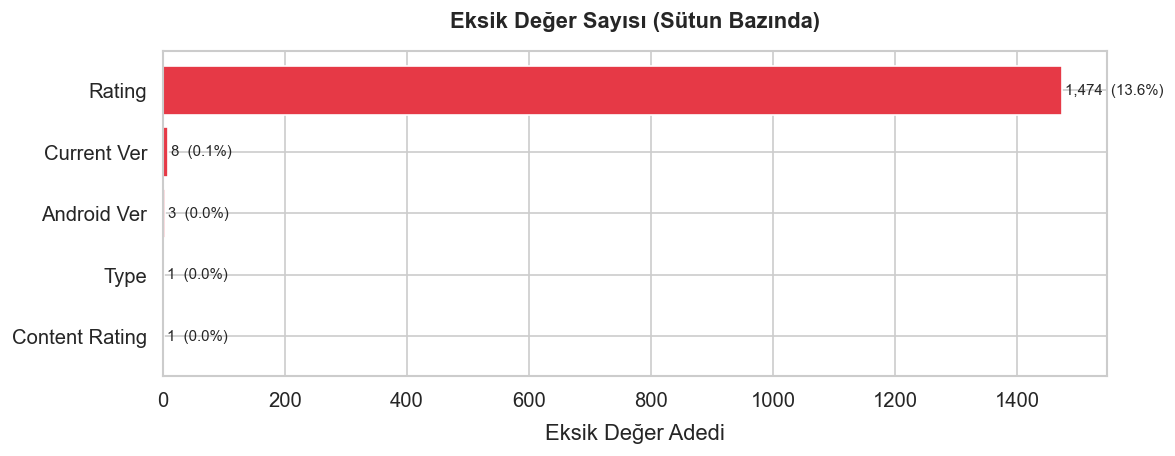

In [5]:
# Eksik değerlerin sütun bazında görselleştirilmesi
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing.values, color=ACCENT, edgecolor='white')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_title('Eksik Değer Sayısı (Sütun Bazında)', fontweight='bold')
ax.set_xlabel('Eksik Değer Adedi')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 3. Veri Temizleme

Ham veri birçok kirli içerik barındırır. Her adımı **gerekçesiyle** birlikte uyguluyoruz:

| Adım | Sütun | Sorun | Çözüm |
|---|---|---|---|
| 3.1 | `Reviews` | Hatalı satır (10472), object tipi | Satırı sil, int'e çevir |
| 3.2 | `Size` | `'M'`, `'k'`, `'Varies with device'` | Birim dönüşümü → float |
| 3.3 | `Installs` / `Price` | `'+'`, `','`, `'$'` karakterleri | Temizle → numeric |
| 3.4 | `Last Updated` | String tarih | datetime + Day/Month/Year ayrıştır |
| 3.5 | `App` | Mükerrer satırlar | İlk oluşumu koru, diğerlerini sil |
| 3.6 | `Android Ver` | `'and up'`, `'Varies with device'`, aralıklar | Temizle → float |

In [6]:
# Orijinal veriyi koruyalım; temizleme işlemlerini kopya üzerinde yapalım
df_clean = df.copy()
print(f'Başlangıç satır sayısı: {len(df_clean):,}')

Başlangıç satır sayısı: 10,841


### 3.1 Reviews Sütunu

10472. satır hatalı girilmiş — `Reviews` sütununda sayısal olmayan bir değer bulunuyor.  
Bu satırı tespit edip silerek sütunu `int`'e dönüştürüyoruz."

In [7]:
# Sayısal olmayan Reviews değerini tespit et
bad_reviews = df_clean[~df_clean['Reviews'].str.isnumeric()]
print(f'Sayısal olmayan Reviews satırı: {len(bad_reviews)} adet')
print(bad_reviews[['App', 'Category', 'Reviews']].to_string())

# Hatalı satırı sil
df_clean = df_clean.drop(df_clean.index[10472])

# Tip dönüşümü
df_clean['Reviews'] = df_clean['Reviews'].astype(int)
print(f'\n✅ Reviews → int. Kalan satır: {len(df_clean):,}')

Sayısal olmayan Reviews satırı: 1 adet
                                           App Category Reviews
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    3.0M

✅ Reviews → int. Kalan satır: 10,840


### 3.2 Size Sütunu

Size değerleri üç farklı formatta geliyor:  
- `'19M'` → MB cinsinden (× 1000 yaparak KB'a çeviriyoruz)  
- `'512k'` → KB cinsinden (k harfini silmek yeterli)  
- `'Varies with device'` → Bilinmeyen → `NaN`

> Not: Boyutu tek bir birimde (KB) tutmak model eğitimi için daha temiz olur.

In [8]:
# 'M' → '000' (MB'ı KB'a çevir), 'k' → '' (zaten KB)
df_clean['Size'] = df_clean['Size'].str.replace('M', '000', regex=False)
df_clean['Size'] = df_clean['Size'].str.replace('k', '', regex=False)

# 'Varies with device' → NaN
df_clean['Size'] = df_clean['Size'].replace('Varies with device', np.nan)

# float'a çevir
df_clean['Size'] = df_clean['Size'].astype(float)

nan_size = df_clean['Size'].isnull().sum()
print(f'✅ Size → float. NaN sayısı (Varies with device): {nan_size:,}')

✅ Size → float. NaN sayısı (Varies with device): 1,695


### 3.3 Installs ve Price Sütunları

`Installs`: `'1,000,000+'` formatında geliyor — `+`, `,` işaretleri kaldırılıp `int`'e çevriliyor.  
`Price`: `'$4.99'` formatında geliyor — `$` işareti kaldırılıp `float`'a çevriliyor.

In [9]:
chars_to_remove = ['+', ',', '$']
cols_to_clean   = ['Installs', 'Price']

for char in chars_to_remove:
    for col in cols_to_clean:
        df_clean[col] = df_clean[col].str.replace(char, '', regex=False)

df_clean['Price']    = df_clean['Price'].astype(float)
df_clean['Installs'] = df_clean['Installs'].astype(int)

print('✅ Price → float, Installs → int')
print(f'   Price   benzersiz değer sayısı  : {df_clean["Price"].nunique()}')
print(f'   Installs benzersiz değer sayısı : {df_clean["Installs"].nunique()}')

✅ Price → float, Installs → int
   Price   benzersiz değer sayısı  : 92
   Installs benzersiz değer sayısı : 20


### 3.4 Last Updated — Tarih Ayrıştırma

`Last Updated` sütunu `'January 7, 2018'` formatında string olarak geliyor.  
`pd.to_datetime()` ile parse edip **Day**, **Month**, **Year** bileşenlerine ayırıyoruz.  
Bu sayede tarihin sayısal bileşenleri model özelliği olarak kullanılabilir hale gelir.

In [10]:
df_clean['Last Updated'] = pd.to_datetime(df_clean['Last Updated'])
df_clean['Day']   = df_clean['Last Updated'].dt.day
df_clean['Month'] = df_clean['Last Updated'].dt.month
df_clean['Year']  = df_clean['Last Updated'].dt.year

print('✅ Tarih ayrıştırıldı: Day, Month, Year sütunları oluşturuldu.')
print(f"   Yıl aralığı: {df_clean['Year'].min()} – {df_clean['Year'].max()}")
print(df_clean[['Last Updated', 'Day', 'Month', 'Year']].head(3).to_string())

✅ Tarih ayrıştırıldı: Day, Month, Year sütunları oluşturuldu.
   Yıl aralığı: 2010 – 2018
  Last Updated  Day  Month  Year
0   2018-01-07    7      1  2018
1   2018-01-15   15      1  2018
2   2018-08-01    1      8  2018


### 3.5 Mükerrer Uygulama Kayıtları

Aynı uygulama birden fazla satırda bulunabilir (farklı sürümler, güncellemeler vs.).  
**İlk oluşumu** koruyup diğerlerini siliyoruz — bu yaklaşım veri kaybını minimize eder.

In [11]:
n_dup = df_clean.duplicated('App').sum()
print(f'Mükerrer App satırı: {n_dup:,}')

df_clean = df_clean.drop_duplicates(subset=['App'], keep='first')
print(f'✅ Tekilleştirme sonrası satır sayısı: {len(df_clean):,}')

Mükerrer App satırı: 1,181
✅ Tekilleştirme sonrası satır sayısı: 9,659


### 3.6 Android Ver Sütunu

Android sürümü birçok farklı formatta geliyor:  
- `'4.1 and up'` → `'and up'` kaldırılacak  
- `'Varies with device'` → `NaN`  
- `'4.1 - 7.1.1'` (aralık format) → aralık içeren satırlar çıkarılacak (model için belirsiz)

Temizlenen sütun sonunda `float`'a çevrilebilecek hale gelir.

In [12]:
# 'and up' ifadesini kaldır
df_clean['Android Ver'] = df_clean['Android Ver'].str.replace('and up', '', regex=False).str.strip()

# 'Varies with device' ve 'W' → NaN
df_clean['Android Ver'] = (
    df_clean['Android Ver']
    .replace('Varies with device', np.nan)
    .replace('W', np.nan)
    .replace('', np.nan)
)

# Aralık formatındaki satırları çıkar (örn. '4.1 - 7.1.1')
n_range = df_clean['Android Ver'].str.contains('-', na=False).sum()
print(f'Aralık formatlı Android Ver satırı: {n_range}')
df_clean = df_clean.loc[~df_clean['Android Ver'].str.contains('-', na=False)]

print(f'✅ Android Ver temizlendi. Kalan satır: {len(df_clean):,}')
print(f'   Benzersiz değer sayısı: {df_clean["Android Ver"].nunique()}')

Aralık formatlı Android Ver satırı: 9
✅ Android Ver temizlendi. Kalan satır: 9,650
   Benzersiz değer sayısı: 25


In [13]:
# Temizleme sonrası özet
print('=== Temizleme Sonrası Veri Seti ===')
print(f'Boyut       : {df_clean.shape[0]:,} satır × {df_clean.shape[1]} sütun')
print(f'Eksik değer : {df_clean.isnull().sum().sum()}')
df_clean.info()

=== Temizleme Sonrası Veri Seti ===
Boyut       : 9,650 satır × 16 sütun
Eksik değer : 3689
<class 'pandas.core.frame.DataFrame'>
Index: 9650 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9650 non-null   object        
 1   Category        9650 non-null   object        
 2   Rating          8189 non-null   float64       
 3   Reviews         9650 non-null   int64         
 4   Size            8423 non-null   float64       
 5   Installs        9650 non-null   int64         
 6   Type            9649 non-null   object        
 7   Price           9650 non-null   float64       
 8   Content Rating  9650 non-null   object        
 9   Genres          9650 non-null   object        
 10  Last Updated    9650 non-null   datetime64[ns]
 11  Current Ver     9642 non-null   object        
 12  Android Ver     8658 non-null   object        
 13  Day             9650

---
## 4. Özellik Tipi Analizi

Sayısal ve kategorik özellikleri ayrıştırarak her gruba uygun analiz stratejisi belirliyoruz.  
Bu adım, hangi sütunlara KDE/histogram, hangilerine countplot uygulanacağını belirler.

In [14]:
numeric_features     = [c for c in df_clean.columns if df_clean[c].dtype != 'O']
categorical_features = [c for c in df_clean.columns if df_clean[c].dtype == 'O']

print(f'Sayısal özellikler ({len(numeric_features)})    : {numeric_features}')
print(f'Kategorik özellikler ({len(categorical_features)}) : {categorical_features}')

Sayısal özellikler (9)    : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']
Kategorik özellikler (7) : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


---
## 5. Sayısal Özellik Dağılımları

Her sayısal özellik için **KDE (Kernel Density Estimation)** grafiği çiziyoruz.  
KDE, histogramın süreklilik kazandırılmış halidir — dağılım şekli, çarpıklık ve aykırı değer bölgeleri görünür hale gelir.  
Ayrıca **kutu grafiği** ile merkez ve yayılım bir arada inceleniyor.

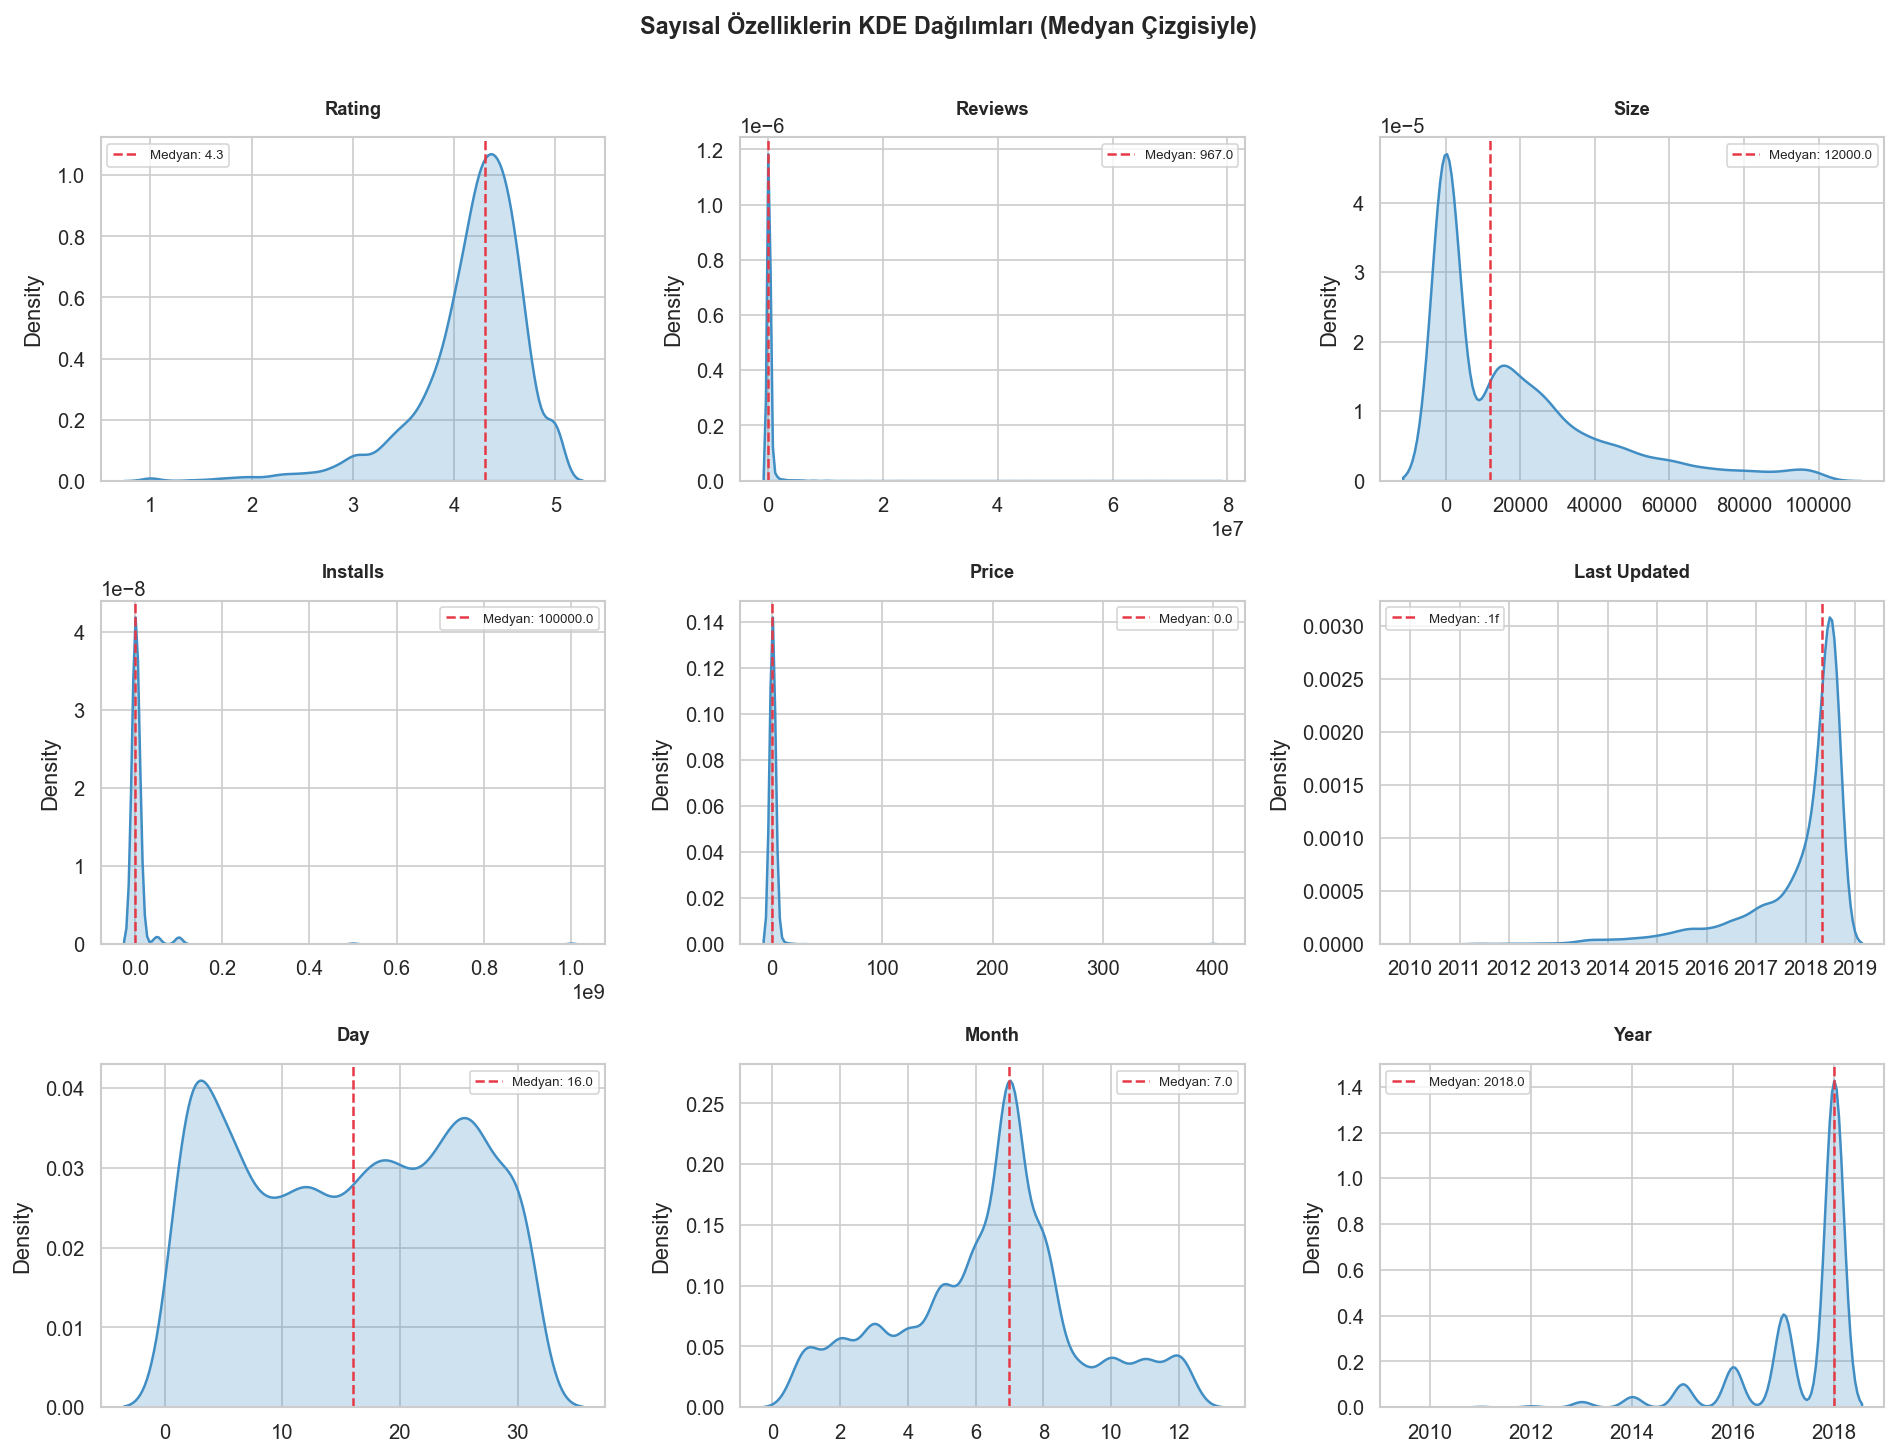

In [15]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    sns.kdeplot(
        x=df_clean[feat].dropna(),
        fill=True, color=PALETTE[4],
        linewidth=1.5, ax=axes[i]
    )
    axes[i].axvline(df_clean[feat].median(), color=ACCENT, ls='--', lw=1.5,
                    label=f'Medyan: {df_clean[feat].median():.1f}')
    axes[i].set_title(feat, fontweight='bold', fontsize=11)
    axes[i].set_xlabel(None)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sayısal Özelliklerin KDE Dağılımları (Medyan Çizgisiyle)',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

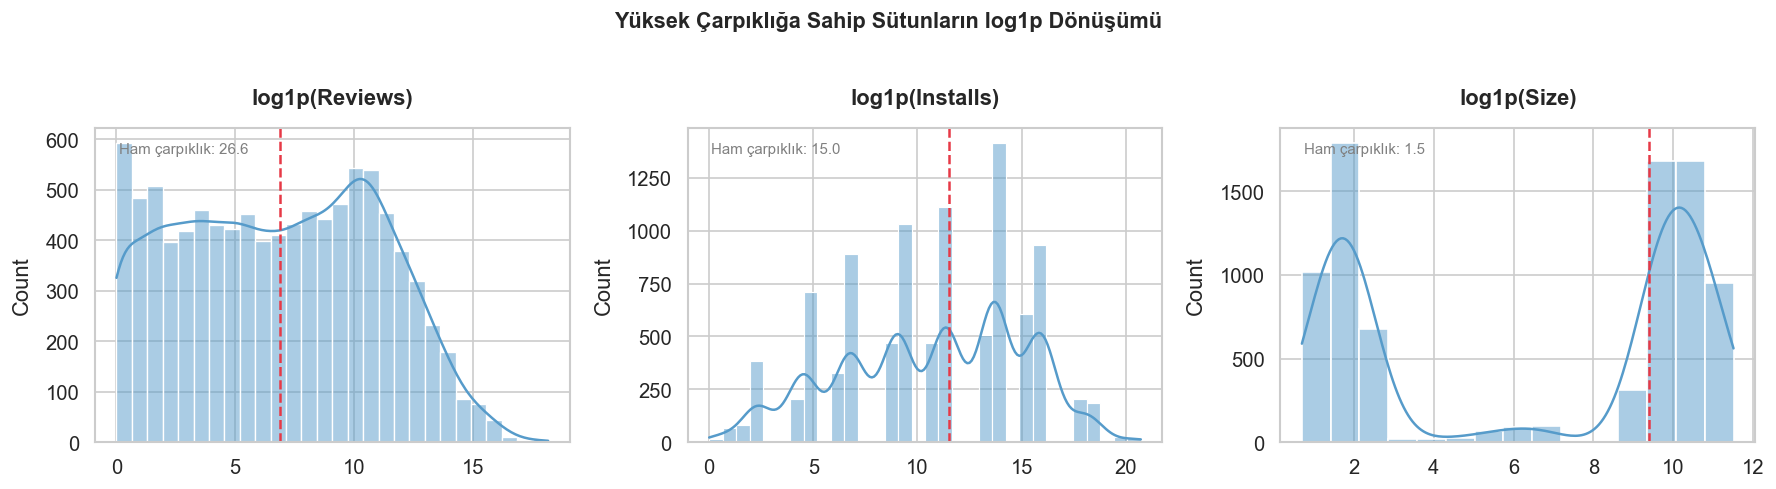

In [16]:
# Log-dönüşümlü dağılım — sağa çarpık sütunlar için (Reviews, Installs, Size)
skewed_cols = ['Reviews', 'Installs', 'Size']

fig, axes = plt.subplots(1, len(skewed_cols), figsize=(15, 4))

for i, col in enumerate(skewed_cols):
    data = np.log1p(df_clean[col].dropna())
    sns.histplot(data, kde=True, color=PALETTE[3], edgecolor='white', ax=axes[i])
    axes[i].axvline(data.median(), color=ACCENT, ls='--', lw=1.5)
    axes[i].set_title(f'log1p({col})', fontweight='bold')
    axes[i].set_xlabel(None)
    skew_val = df_clean[col].dropna().skew()
    axes[i].annotate(f'Ham çarpıklık: {skew_val:.1f}',
                     xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9, color='gray')

plt.suptitle('Yüksek Çarpıklığa Sahip Sütunların log1p Dönüşümü',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Kategorik Özellik Dağılımları

`Type` ve `Content Rating` sütunlarını **countplot** ile inceliyoruz.  
Countplot, her kategori için kayıt sayısını gösterir ve sınıf dengesizliklerini hemen açığa çıkarır.

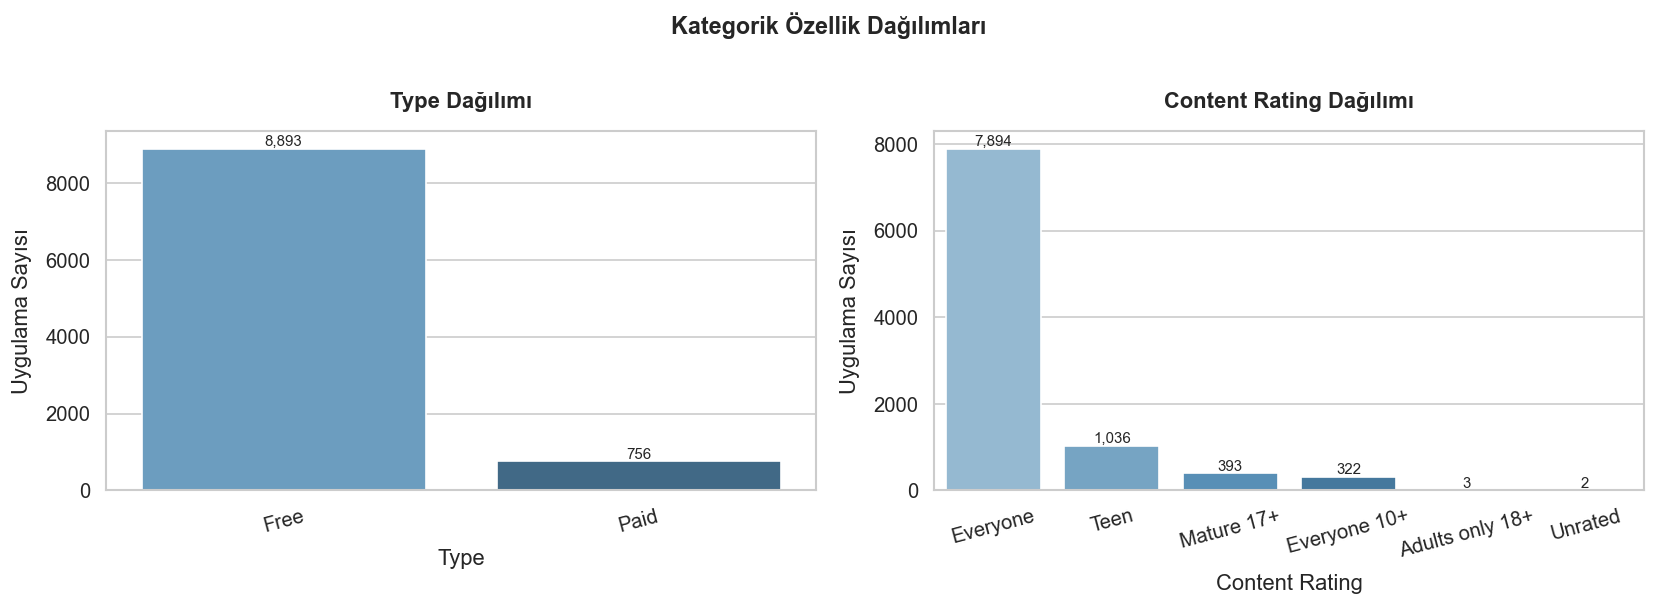

In [17]:
category_cols = ['Type', 'Content Rating']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(category_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(x=df_clean[col], order=order, palette='Blues_d', ax=axes[i])
    axes[i].set_title(f'{col} Dağılımı', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Uygulama Sayısı')
    axes[i].tick_params(axis='x', rotation=15)
    # Çubukların üstüne sayı yaz
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height()):,}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

plt.suptitle('Kategorik Özellik Dağılımları', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Kategori Bazında Kurulum Analizi

### 7.1 En Popüler 10 Kategori (Toplam Kurulum Sayısı)

`groupby` ile her kategorinin **toplam kurulum sayısını** hesaplıyoruz.  
Milyar biriminde göstermek için 10⁹'a bölüyoruz — bu sayede eksen etiketleri okunabilir kalır.

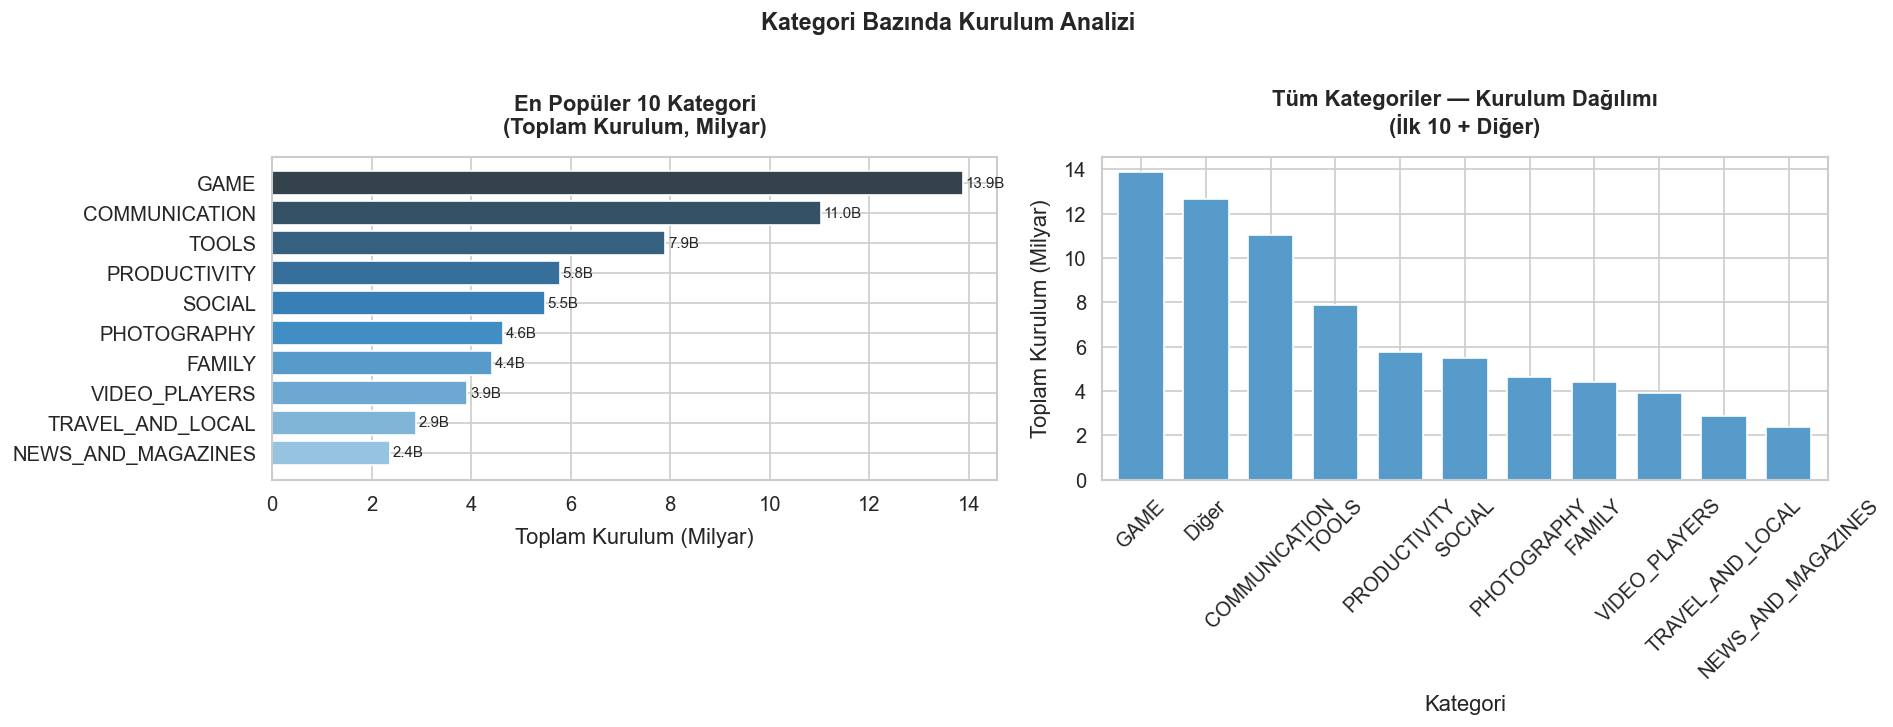

In [18]:
df_cat_installs = (
    df_clean.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
df_cat_installs['Installs_B'] = df_cat_installs['Installs'] / 1_000_000_000

top10 = df_cat_installs.head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Yatay bar — ilk 10
bars = axes[0].barh(top10['Category'][::-1], top10['Installs_B'][::-1],
                    color=PALETTE, edgecolor='white')
for bar, val in zip(bars, top10['Installs_B'][::-1]):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}B', va='center', fontsize=9)
axes[0].set_title('En Popüler 10 Kategori\n(Toplam Kurulum, Milyar)', fontweight='bold')
axes[0].set_xlabel('Toplam Kurulum (Milyar)')

# Tüm kategoriler — pasta grafiği alternatifi: treemap benzeri bar
df_all = df_cat_installs.copy()
df_all.loc[df_all.index[10:], 'Category'] = 'Diğer'
df_grouped = df_all.groupby('Category')['Installs_B'].sum().sort_values(ascending=False)
df_grouped.plot(kind='bar', ax=axes[1], color=PALETTE[3], edgecolor='white', width=0.7)
axes[1].set_title('Tüm Kategoriler — Kurulum Dağılımı\n(İlk 10 + Diğer)', fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Toplam Kurulum (Milyar)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Kategori Bazında Kurulum Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 En Popüler 5 Kategorideki En Çok İndirilen 5 Uygulama

Her kategori için **ilk 5 uygulamayı** ayrı panellerde görselleştiriyoruz.  
Bu analiz; hangi uygulamaların kategorilerinde baskın olduğunu ve kurulum sayılarının ne kadar asimetrik dağıldığını gösterir.

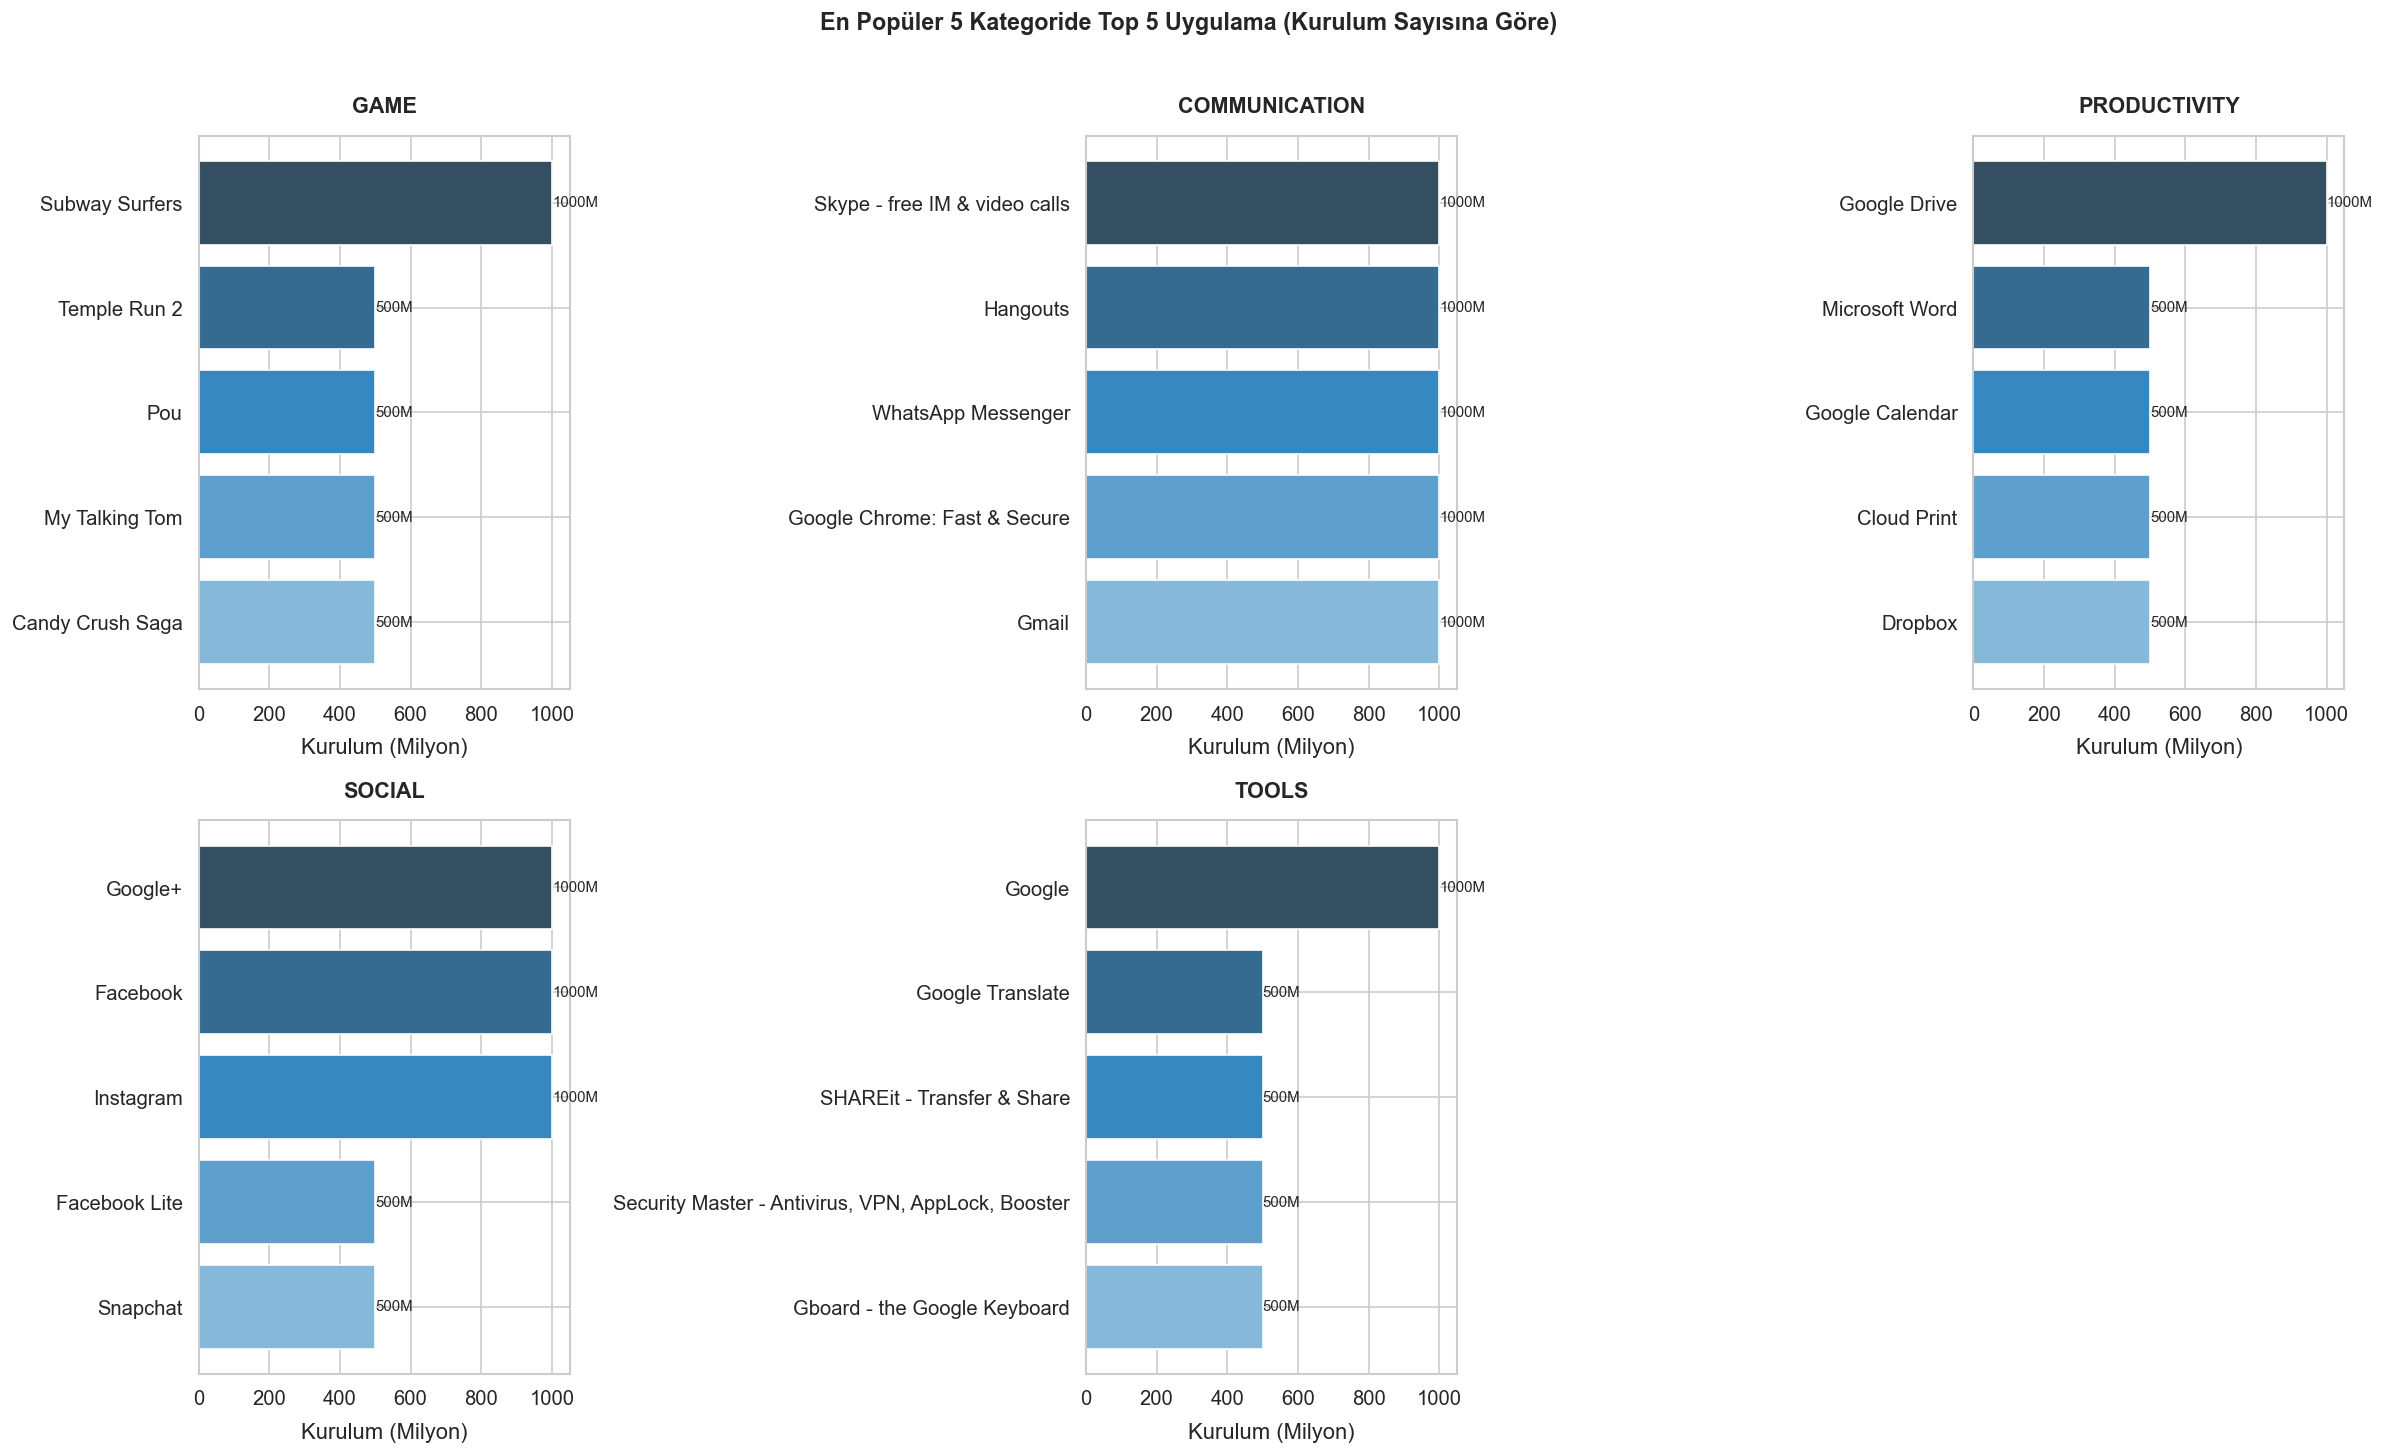

In [19]:
df_app_category = (
    df_clean.groupby(['Category', 'App'])['Installs']
    .sum()
    .reset_index()
    .sort_values('Installs', ascending=False)
)

TOP_CATS = ['GAME', 'COMMUNICATION', 'PRODUCTIVITY', 'SOCIAL', 'TOOLS']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, cat in enumerate(TOP_CATS):
    df_top5 = df_app_category[df_app_category['Category'] == cat].head(5).copy()
    df_top5['Installs_M'] = df_top5['Installs'] / 1_000_000

    bars = axes[i].barh(
        df_top5['App'][::-1], df_top5['Installs_M'][::-1],
        color=sns.color_palette('Blues_d', 5), edgecolor='white'
    )
    for bar, val in zip(bars, df_top5['Installs_M'][::-1]):
        axes[i].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}M', va='center', fontsize=9)
    axes[i].set_title(cat, fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Kurulum (Milyon)')

axes[-1].axis('off')  # Son panel boş

plt.suptitle('En Popüler 5 Kategoride Top 5 Uygulama (Kurulum Sayısına Göre)',
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Puan (Rating) Analizi

### 8.1 Tam Puan (5.0) Alan Uygulamalar

5.0 puan alan uygulamaların sayısını ve kategori dağılımını inceliyoruz.  
Bu uygulamalar genellikle az yorum almış nişe özel uygulamalardır — dolayısıyla "en iyi" olarak yorumlanamaz.

5.0 puan alan uygulama sayısı: 271


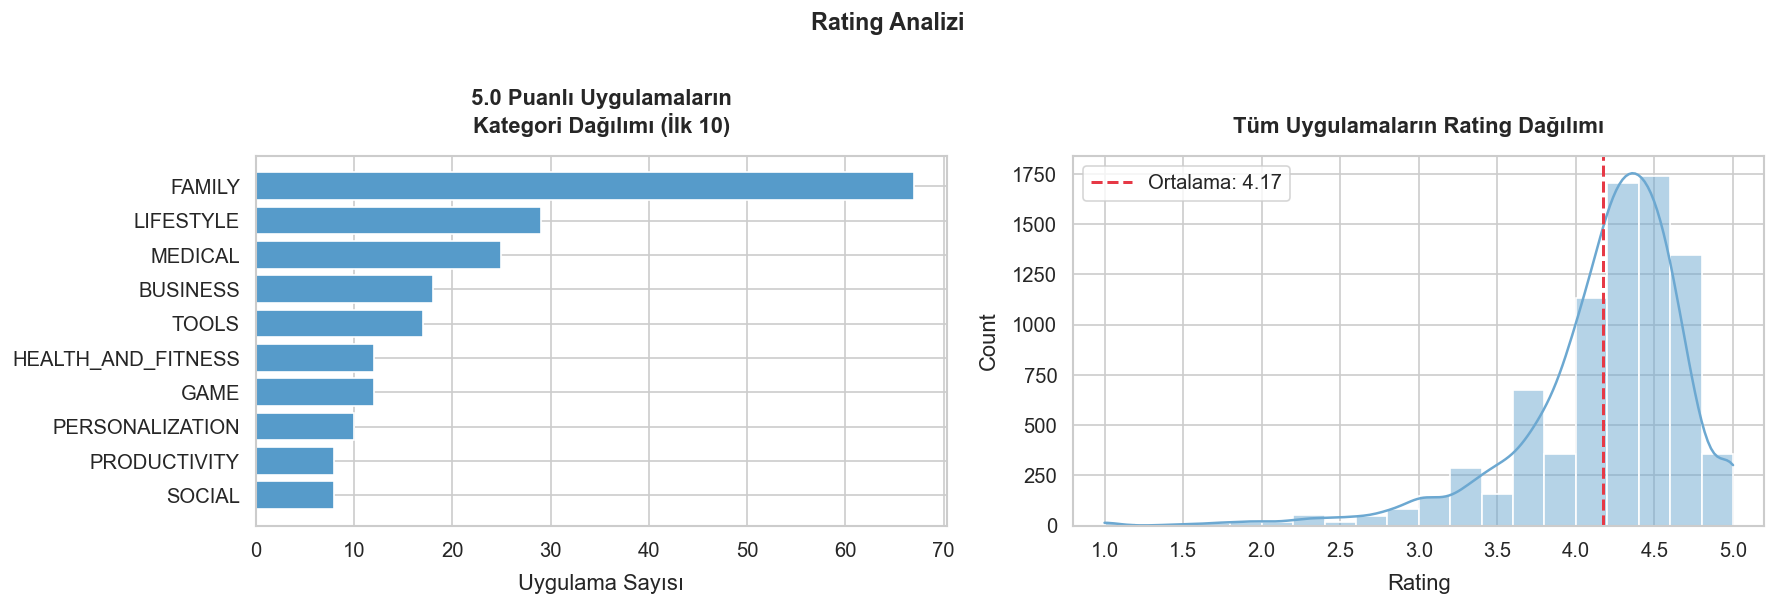

In [20]:
rating_df = (
    df_clean.groupby(['Category', 'Installs', 'App'])['Rating']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
top_rated = rating_df[rating_df['Rating'] == 5.0]

print(f'5.0 puan alan uygulama sayısı: {len(top_rated)}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Kategori dağılımı
top_rated_cats = top_rated['Category'].value_counts().head(10)
axes[0].barh(top_rated_cats.index[::-1], top_rated_cats.values[::-1],
             color=PALETTE[3], edgecolor='white')
axes[0].set_title('5.0 Puanlı Uygulamaların\nKategori Dağılımı (İlk 10)', fontweight='bold')
axes[0].set_xlabel('Uygulama Sayısı')

# Tüm Rating dağılımı
sns.histplot(df_clean['Rating'].dropna(), bins=20, kde=True,
             color=PALETTE[2], edgecolor='white', ax=axes[1])
axes[1].axvline(df_clean['Rating'].mean(), color=ACCENT, ls='--', lw=1.8,
                label=f"Ortalama: {df_clean['Rating'].mean():.2f}")
axes[1].set_title('Tüm Uygulamaların Rating Dağılımı', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].legend()

plt.suptitle('Rating Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Rating × Installs × Type İlişkisi

Puan ile kurulum sayısı arasındaki ilişkiyi `Type` (Ücretsiz/Ücretli) renk kodlamasıyla görselleştiriyoruz.  
Beklenti: daha fazla kullanıcıya sahip uygulamaların puan ortalamaları daha stabil olmalı.

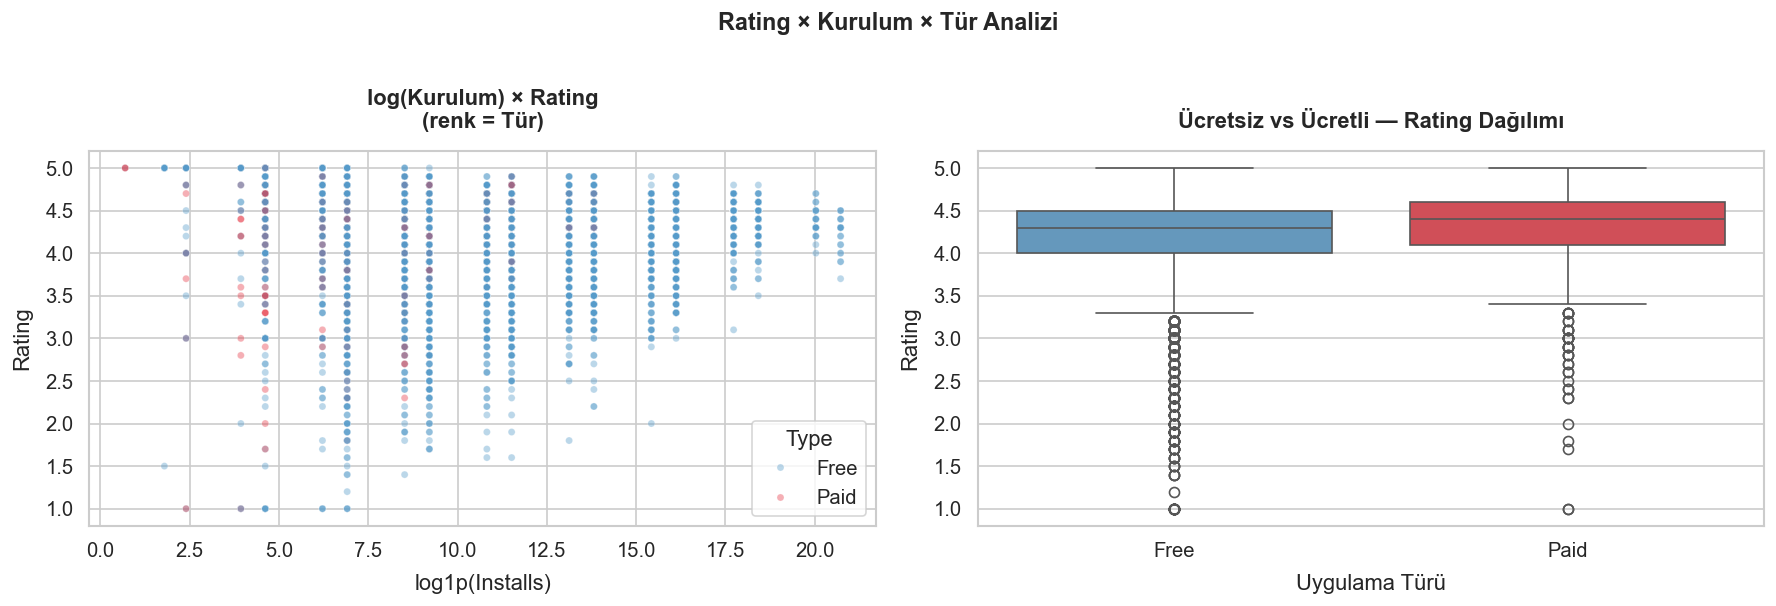

In [21]:
plot_df = df_clean[df_clean['Rating'].notna() & df_clean['Type'].isin(['Free', 'Paid'])].copy()
plot_df['log_Installs'] = np.log1p(plot_df['Installs'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: log(Installs) vs Rating
sns.scatterplot(
    data=plot_df, x='log_Installs', y='Rating',
    hue='Type', palette={'Free': PALETTE[3], 'Paid': ACCENT},
    alpha=0.4, s=18, ax=axes[0]
)
axes[0].set_title('log(Kurulum) × Rating\n(renk = Tür)', fontweight='bold')
axes[0].set_xlabel('log1p(Installs)')
axes[0].set_ylabel('Rating')

# Boxplot: Type vs Rating
sns.boxplot(
    data=plot_df, x='Type', y='Rating',
    palette={'Free': PALETTE[3], 'Paid': ACCENT},
    ax=axes[1]
)
axes[1].set_title('Ücretsiz vs Ücretli — Rating Dağılımı', fontweight='bold')
axes[1].set_xlabel('Uygulama Türü')
axes[1].set_ylabel('Rating')

plt.suptitle('Rating × Kurulum × Tür Analizi', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Korelasyon Matrisi

Sayısal özellikler arasındaki **Pearson korelasyonunu** ısı haritasıyla görselleştiriyoruz.  
Özellikle `Reviews–Installs` gibi güçlü korelasyonlar, model için **çoklu doğrusallık riski** taşır.

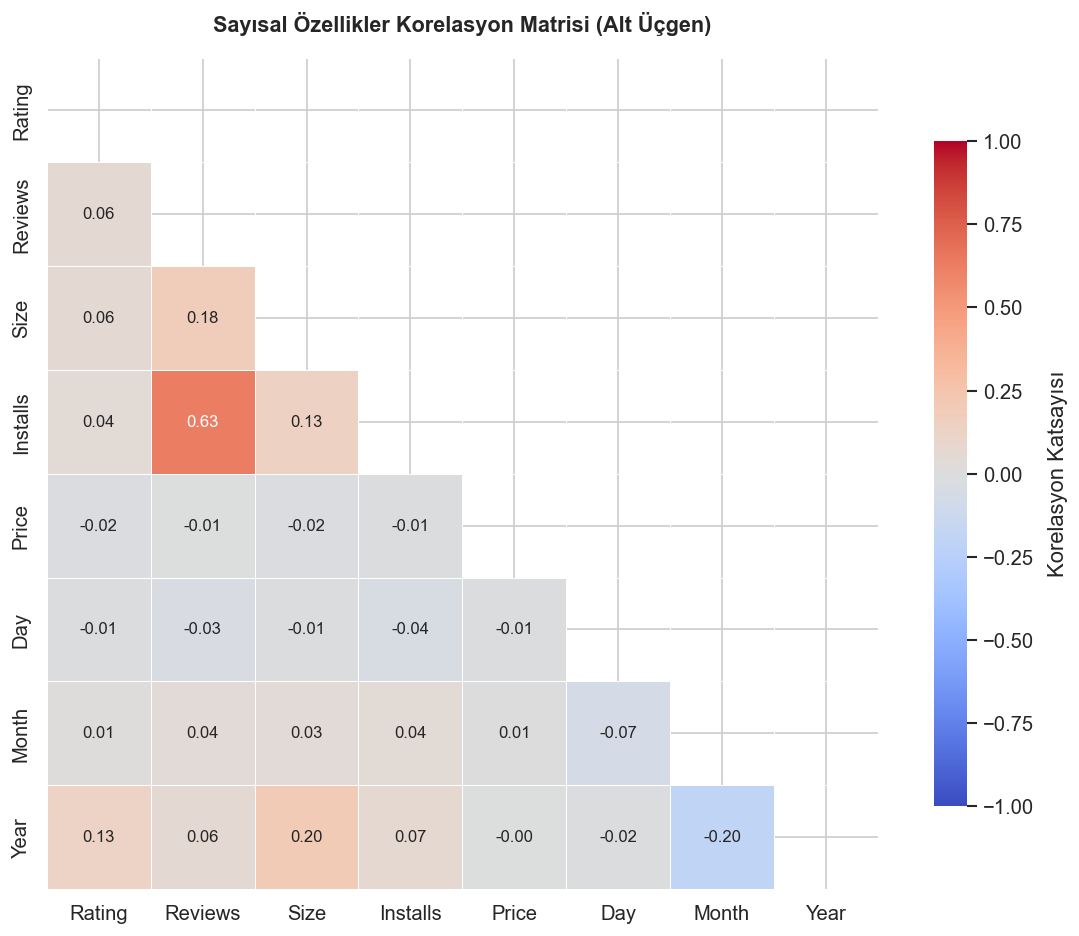


📈 Rating ile korelasyon (mutlak değer, büyükten küçüğe):
Year        0.125913
Size        0.061334
Reviews     0.055108
Installs    0.040161
Price      -0.021183
Month       0.011405
Day        -0.010252


In [22]:
corr_cols = ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'Year']
corr = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Korelasyon Katsayısı'},
    ax=ax
)
ax.set_title('Sayısal Özellikler Korelasyon Matrisi (Alt Üçgen)',
             fontsize=13, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

# Rating ile korelasyon sıralaması
rating_corr = corr['Rating'].drop('Rating').sort_values(key=abs, ascending=False)
print('\n📈 Rating ile korelasyon (mutlak değer, büyükten küçüğe):')
print(rating_corr.to_string())

---
## 10. Özellik Mühendisliği — Target Mean Encoding

Kategorik sütunları makine öğrenmesi modelleri için sayısal forma çevirmemiz gerekir.  
**Target Mean Encoding**, her kategori için **hedef değişkenin ortalamasını** kod olarak kullanır.

**Neden OHE yerine?**  
- `Genres` sütununda 100+ benzersiz değer var → OHE ile 100+ yeni sütun oluşur (boyut patlaması)  
- Target encoding bu boyut problemini ortadan kaldırır  
- Her kategori, hedef ile ilişkisini koruyarak tek bir sayıya indirgenir

> ⚠️ **Veri sızıntısı riski**: Üretim ortamında encoding'i yalnızca **eğitim seti** üzerinde hesaplayıp test setine uygulamak gerekir. Burada tüm veri üzerinde örnek amaçlı gösteriyoruz.

In [23]:
# Genres bazında ortalama kurulum sayısı (milyon)
mean_genres_installs = (
    df_clean.groupby('Genres')['Installs'].mean() / 1_000_000
).to_dict()

df_clean['Genres_Encoded'] = df_clean['Genres'].map(mean_genres_installs)

print(f'Genres benzersiz değer: {df_clean["Genres"].nunique()}')
print(f'Encoding sonrası NaN  : {df_clean["Genres_Encoded"].isnull().sum()}')
print('\nÖrnek encoding (ilk 10 Genres):')
print(pd.Series(mean_genres_installs).sort_values(ascending=False).head(10).to_string())

Genres benzersiz değer: 118
Encoding sonrası NaN  : 0

Örnek encoding (ilk 10 Genres):
Communication                     35.218135
Video Players & Editors           24.178412
Social                            22.961790
Adventure;Action & Adventure      21.230000
Arcade                            20.519831
Casual                            18.502004
Puzzle;Action & Adventure         18.366667
Educational;Action & Adventure    17.016667
Photography                       16.568384
Productivity                      15.504266


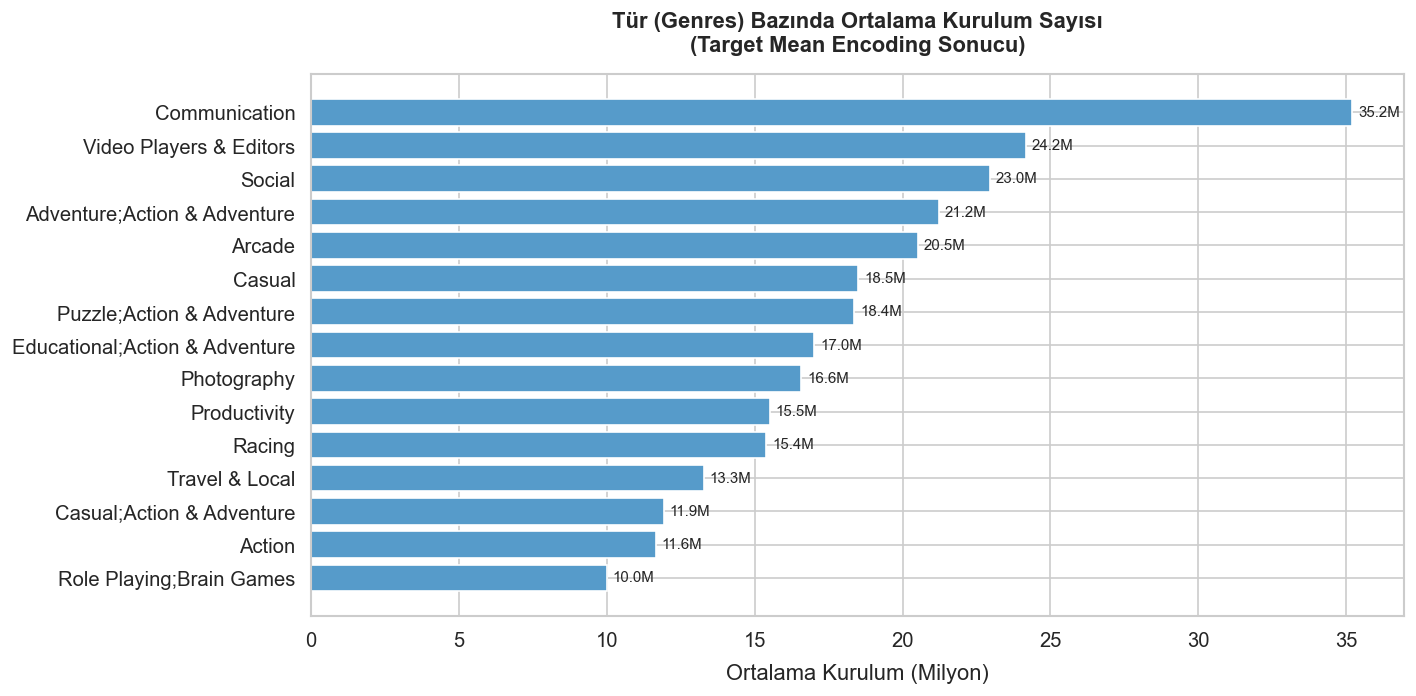

In [24]:
# En yüksek ortalama kuruluma sahip 15 tür
top_genres = pd.Series(mean_genres_installs).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1],
               color=PALETTE[3], edgecolor='white')
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9)
ax.set_title('Tür (Genres) Bazında Ortalama Kurulum Sayısı\n(Target Mean Encoding Sonucu)',
             fontweight='bold')
ax.set_xlabel('Ortalama Kurulum (Milyon)')
plt.tight_layout()
plt.show()

---
## 11. Özet ve Sonraki Adımlar

### ✅ Bu Notebook'ta Yapılanlar

| Adım | İşlem | Gerekçe |
|---|---|---|
| 2 | Ham veri yükleme + eksik değer haritası | İlk kalite kontrolü |
| 3.1 | Reviews temizleme | Hatalı satır + tip dönüşümü |
| 3.2 | Size birim dönüşümü (M/k → float KB) | Homojen birim |
| 3.3 | Installs / Price karakter temizleme | Sayısal tip |
| 3.4 | Tarih ayrıştırma | Day/Month/Year özellikleri |
| 3.5 | Mükerrer satır silme | Veri bütünlüğü |
| 3.6 | Android Ver temizleme | Belirsiz değerleri kaldır |
| 4 | Sayısal/kategorik özellik ayrımı | Analiz stratejisi |
| 5 | KDE + log dağılımları | Çarpıklık tespiti |
| 6 | Countplot | Sınıf dengesi |
| 7 | Kategori ve uygulama bazında kurulum | Popülerlik analizi |
| 8 | Rating analizi + scatter | Puan kalitesi |
| 9 | Korelasyon matrisi | Özellik ilişkileri |
| 10 | Target Mean Encoding (Genres) | Boyut azaltma |

### 🔑 Temel Bulgular

- **GAME** ve **COMMUNICATION** kategorileri kurulum sayısında baskın durumda.
- **Reviews** ile **Installs** arasında çok güçlü pozitif korelasyon var → birini model dışı bırakmak mantıklı olabilir.
- Uygulama Rating dağılımı **sola çarpık** — çoğu uygulama 4.0+ puan alıyor.
- **Ücretli uygulamalar** genellikle daha yüksek medyan rating'e sahip, ancak sayıları çok az.
- 5.0 puan alan 271 uygulama var, bunların büyük çoğunluğu **az review** almış nişe uygulamalar.

### 🔮 Sonraki Adımlar

1. **Aykırı değer işleme** — Reviews ve Installs'ta üst sınır kırpma (winsorizing)
2. **Hedef değişken seçimi** — Rating tahmini (regresyon) veya popülerlik sınıflandırması
3. **Category encoding** — Target encoding veya frequency encoding
4. **Özellik seçimi** — VIF analizi, korelasyon temelli eleme
5. **Model eğitimi** — Baseline: Linear Regression veya Random Forest
6. **Veri sızıntısı önlemi** — Target encoding'i pipeline içinde sadece train setine uygula
